# Lab-7: Variational Autoencoder (VAE) on MNSIT Dataset:
## Reg.No: 2548514

### Install & Import Libraries:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

### Load MNIST Dataset:

In [2]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

100%|██████████| 9.91M/9.91M [00:00<00:00, 36.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 971kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.12MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.68MB/s]


### Define VAE Architecture:
Encoder + Latent Space + Decoder

In [15]:
class VAE(nn.Module):

    def __init__(self):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(784, 400)

        self.fc_mu = nn.Linear(400, 20)
        self.fc_logvar = nn.Linear(400, 20)

        # Decoder
        self.fc2 = nn.Linear(20, 400)
        self.fc3 = nn.Linear(400, 784)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):

        h = self.relu(self.fc1(x))

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        z = mu + eps * std

        return z

    def decode(self, z):

        h = self.relu(self.fc2(z))

        reconstruction = self.sigmoid(self.fc3(h))

        return reconstruction

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        reconstruction = self.decode(z)

        return reconstruction, mu, logvar

### Reparameterization Trick:

This samples latent vector z.

In [16]:
    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        z = mu + eps * std

        return z

### Decoder:

Reconstructs original image.

In [17]:
    def decode(self, z):

        h = self.relu(self.fc2(z))

        reconstruction = self.sigmoid(self.fc3(h))

        return reconstruction

### Forward Pass:

In [18]:
    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        reconstruction = self.decode(z)

        return reconstruction, mu, logvar

### Initialize Model:

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

### Define VAE Loss Function:
Reconstruction Loss + KL Divergence

In [20]:
def vae_loss(recon_x, x, mu, logvar):

    reconstruction_loss = nn.functional.binary_cross_entropy(
        recon_x,
        x,
        reduction='sum'
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = reconstruction_loss + kl_loss

    return total_loss, reconstruction_loss, kl_loss

### Training Loop:

In [21]:
epochs = 10

train_losses = []
recon_losses = []
kl_losses = []

for epoch in range(epochs):

    model.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for data, _ in train_loader:

        data = data.view(-1, 784).to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(data)

        loss, r_loss, kl = vae_loss(recon, data, mu, logvar)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()
        total_recon += r_loss.item()
        total_kl += kl.item()

    train_losses.append(total_loss / len(train_loader.dataset))
    recon_losses.append(total_recon / len(train_loader.dataset))
    kl_losses.append(total_kl / len(train_loader.dataset))

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Total Loss: {train_losses[-1]:.4f}")
    print(f"Reconstruction Loss: {recon_losses[-1]:.4f}")
    print(f"KL Divergence Loss: {kl_losses[-1]:.4f}")

Epoch 1/10
Total Loss: 162.8055
Reconstruction Loss: 146.8207
KL Divergence Loss: 15.9848
Epoch 2/10
Total Loss: 120.8199
Reconstruction Loss: 98.4616
KL Divergence Loss: 22.3583
Epoch 3/10
Total Loss: 114.1019
Reconstruction Loss: 90.0642
KL Divergence Loss: 24.0377
Epoch 4/10
Total Loss: 111.2389
Reconstruction Loss: 86.6694
KL Divergence Loss: 24.5695
Epoch 5/10
Total Loss: 109.5560
Reconstruction Loss: 84.6852
KL Divergence Loss: 24.8708
Epoch 6/10
Total Loss: 108.4441
Reconstruction Loss: 83.4311
KL Divergence Loss: 25.0131
Epoch 7/10
Total Loss: 107.6881
Reconstruction Loss: 82.5468
KL Divergence Loss: 25.1413
Epoch 8/10
Total Loss: 107.0104
Reconstruction Loss: 81.8098
KL Divergence Loss: 25.2005
Epoch 9/10
Total Loss: 106.5031
Reconstruction Loss: 81.2371
KL Divergence Loss: 25.2659
Epoch 10/10
Total Loss: 106.1121
Reconstruction Loss: 80.7752
KL Divergence Loss: 25.3370


### Visualization — Loss Curves:

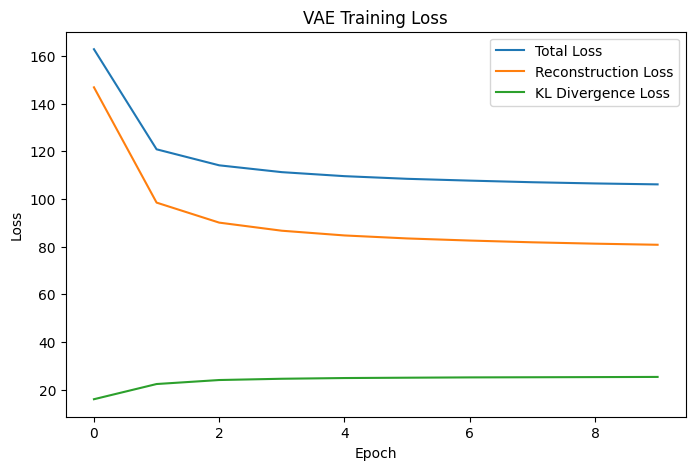

In [22]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Total Loss")
plt.plot(recon_losses, label="Reconstruction Loss")
plt.plot(kl_losses, label="KL Divergence Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.legend()

plt.show()

### Reconstruction Visualization:

Compare original vs reconstructed images.

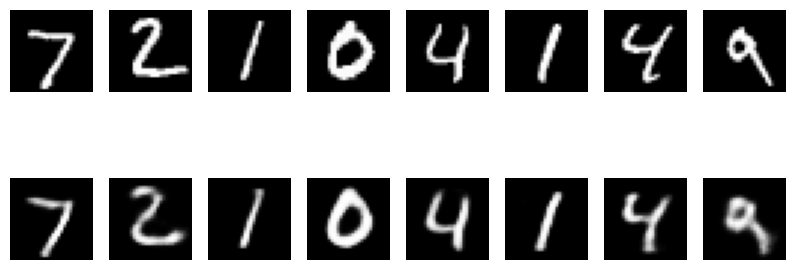

In [24]:
model.eval()

data, _ = next(iter(test_loader))
data = data.view(-1,784).to(device)

recon, _, _ = model(data)

data = data.cpu().view(-1,28,28)
recon = recon.detach().cpu().view(-1,28,28) # Added .detach() here

plt.figure(figsize=(10,4))

for i in range(8):

    plt.subplot(2,8,i+1)
    plt.imshow(data[i], cmap='gray')
    plt.axis('off')

    plt.subplot(2,8,i+9)
    plt.imshow(recon[i], cmap='gray')
    plt.axis('off')

plt.show()

### Latent Space Visualization:

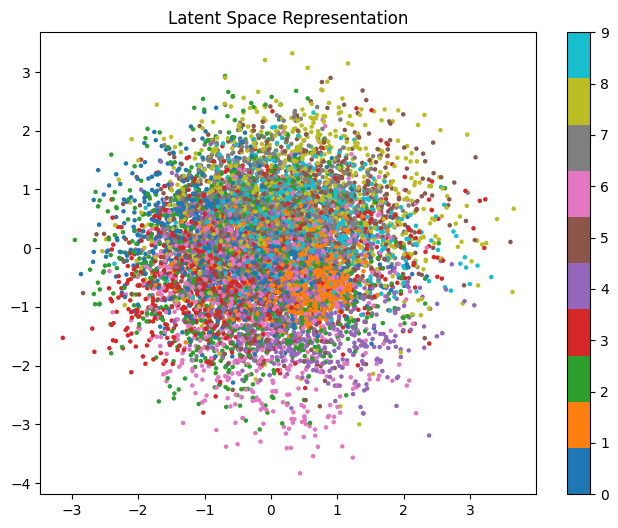

In [25]:
model.eval()

latent_vectors = []
labels = []

with torch.no_grad():

    for data, label in test_loader:

        data = data.view(-1,784).to(device)

        mu, logvar = model.encode(data)

        latent_vectors.append(mu.cpu())
        labels.append(label)

latent_vectors = torch.cat(latent_vectors)
labels = torch.cat(labels)

plt.figure(figsize=(8,6))

plt.scatter(
    latent_vectors[:,0],
    latent_vectors[:,1],
    c=labels,
    cmap='tab10',
    s=5
)

plt.colorbar()
plt.title("Latent Space Representation")
plt.show()